# Analysis

## Data Collection

In [ ]:
import json, calendar
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from fastcore.utils import *

This query aggregates monthly package creation and release data from PyPI's public BigQuery dataset, which we use to plot overall package growth over time (Chart 1). Run it in [BigQuery console](https://console.cloud.google.com/bigquery) and export results to `bquxjob_*.csv`:

In [ ]:

monthly_df = pd.read_csv('bquxjob_3bd11968_19ba66fbefa.csv')
monthly_df.head()

,month,version_releases,new_packages
0,2005-03-01 00:00:00.000000 UTC,4,4
1,2005-04-01 00:00:00.000000 UTC,6,5
2,2005-05-01 00:00:00.000000 UTC,5,2
3,2005-06-01 00:00:00.000000 UTC,5,2
4,2005-07-01 00:00:00.000000 UTC,13,7


Download the list of top PyPI packages by download count. We use this to filter to "real" actively-used packages:

In [ ]:
existing = sorted(Path('.').glob('top-pypi-packages-downloaded-*.csv'))
if existing: pkgs_df = pd.read_csv(existing[-1])
else: pkgs_df = pd.read_csv("https://hugovk.github.io/top-pypi-packages/top-pypi-packages.csv"); pkgs_df.to_csv(f"top-pypi-packages-downloaded-{datetime.now():%Y%m%d}.csv", index=False)
pkgs_df.head()

,download_count,project
0,1438455634,boto3
1,1106102051,urllib3
2,1010375477,botocore
3,990302186,typing-extensions
4,959087169,requests


Scrape PyPI API for release metadata of top 1500 packages (skip if already cached):

In [ ]:
import httpx, time

cache_dir = Path("pypi_cache")
cache_dir.mkdir(exist_ok=True)
top5000 = pkgs_df.head(15000)['project'].tolist()

for pkg in top5000:
    cache_file = cache_dir / f"{pkg}.json"
    if cache_file.exists(): continue
    resp = httpx.get(f"https://pypi.org/pypi/{pkg}/json")
    if resp.status_code == 200: cache_file.write_text(json.dumps(resp.json())); print(f"✓ {pkg}")
    else: print(f"✗ {pkg}: {resp.status_code}")
    time.sleep(0.1)
print(f"\nDone! Cached {len(list(cache_dir.glob('*.json')))} packages")

✗ aaaaaaaaa: 404


✗ python-must: 404

Done! Cached 14998 packages


Extract releases from cached JSON into `releases.csv`:

In [ ]:
import re 
def norm_name(n): return re.sub(r'[-_.]+', '-', str(n)).lower()

In [ ]:
if not Path('releases.csv').exists():
    rows = []
    for f in cache_dir.glob("*.json"):
        data = f.read_json()
        pkg = data['info']['name']
        for version, files in data['releases'].items():
            if files: rows.append(dict(project=pkg, release=version, upload_time=files[0]['upload_time_iso_8601']))
    releases_df = pd.DataFrame(rows)
    releases_df['project'] = releases_df['project'].map(norm_name)
    releases_df.to_csv('releases.csv', index=False)
else: releases_df = pd.read_csv('releases.csv')
print('n projects: ', releases_df['project'].nunique())
releases_df.head()

n projects:  14997


,project,release,upload_time
0,aiotask-context,0.2,2016-09-07T15:25:46.779148Z
1,aiotask-context,0.3,2016-09-29T21:22:51.289208Z
2,aiotask-context,0.4,2017-05-19T18:20:13.085468Z
3,aiotask-context,0.4.1,2017-08-29T14:52:56.790545Z
4,aiotask-context,0.4.2,2017-08-29T20:59:20.982953Z


In [ ]:
releases_df.isna().sum()

project        4
release        0
upload_time    0
dtype: int64

In [ ]:
print(len(releases_df))
releases_df.dropna(inplace=True)
print(len(releases_df))

1224260
1224256


Classify packages as AI-related using OpenAI batch API. First extract descriptions:

In [ ]:
# def get_desc(f):
#     info = json.loads(f.read_text())['info']
#     return dict(project=info['name'], summary=info.get('summary') or '')
# descs = pd.DataFrame([get_desc(f) for f in cache_dir.glob("*.json")])
# descs.head()

Create and submit batch classification job (commented out - only run if `classify_results.jsonl` doesn't exist):

In [ ]:
# from openai import OpenAI
# client = OpenAI()

# requests = []
# for _, row in descs.iterrows():
#     if row['project'] in classifications: continue
#     requests.append(dict(custom_id=row['project'], method="POST", url="/v1/chat/completions",
#         body=dict(model="gpt-5.2", max_completion_tokens=5, messages=[
#             dict(role="system", content="Classify if this Python package is AI-related (machine learning, LLMs, neural networks, AI infrastructure, deep learning, GPUs, etc). Reply with just 'True' or 'False'."),
#             dict(role="user", content=f"{row['project']}: {row['summary']}")])))

# Path("classify_requests.jsonl").write_text('\n'.join(json.dumps(r) for r in requests))
# batch_file = client.files.create(file=open("classify_requests.jsonl", "rb"), purpose="batch")
# batch_job = client.batches.create(input_file_id=batch_file.id, endpoint="/v1/chat/completions", completion_window="24h")
# print(f"Batch job: {batch_job.id}, Status: {batch_job.status}")

Check batch status and download results:

In [ ]:
# status = client.batches.retrieve(batch_job.id)
# print(f"Status: {status.status}, Completed: {status.request_counts.completed}/{status.request_counts.total}")
# if status.output_file_id:
#     Path("classify_results.jsonl").write_text(client.files.content(status.output_file_id).text)
#     print(f"Downloaded results")

In [ ]:
classifications = {(r := json.loads(line))['custom_id']: r['response']['body']['choices'][0]['message']['content'].strip().lower() == 'true' for line in Path("classify_results.jsonl").read_text().splitlines()}
classifications = {norm_name(k): v for k,v in classifications.items()}

In [ ]:
len(classifications)

14998

In [ ]:
ratings = {
  "jupyter-sphinx": False,
  "typing-inspection": False,
  "autologging": False,
  "pins": False,
  "ell-ai": True,
  "onemkl-sycl-sparse": True,
  "warp-lang": True,
  "repoze-who": False,
  "mlxtend": True,
  "hf-xet": True,
  "llama-index-legacy": True,
  "awslabs-mysql-mcp-server": True,
  "mysql": False,
  "langchain-together": True,
  "ipytablewidgets": False,
  "banks": True,
  "laboratory": False,
  "pgdb": False,
  "livekit-plugins-deepgram": True,
  "cleanvoice-sdk": True,
  "anytree": False,
  "arviz-stats": False,
  "hyppo": False,
  "beeai-framework": True,
  "opentelemetry-instrumentation-aiohttp-server": False,
  "captum": True,
  "keras-core": True,
  "large-image-source-nd2": False,
  "openai-whisper": True,
  "openapi-codec": False,
  "chainlit": True,
  "tensorzero": True,
  "behavex": False,
  "face-recognition-models": True,
  "docutils-stubs": False,
  "keras-preprocessing": True,
  "mnemonic": False,
  "requests-html": False,
  "nvidia-cuda-cccl": True,
  "fastapi-mcp": True,
  "rensa": False,
  "fastcluster": True,
  "scikit-base": True,
  "egobox": False,
  "onnx-weekly": True,
  "promptflow-core": True,
  "nanopb": False,
  "rmm-cu12": True,
  "textfsm": False,
  "rapidocr-onnxruntime": True,
  "prodigyopt": True,
  "fastcore": True,
  "mkl": False,
  "dipy": True,
  "opentelemetry-instrumentation-sagemaker": True,
  "jupyter-bbox-widget": False,
  "optax": True,
  "idf-component-manager": False,
  "amazon-textract-prettyprinter": True,
  "asciidag": False,
  "dep-logic": False,
  "types-click-spinner": False,
  "cachetools": False,
  "xtcocotools": True,
  "brotli": False,
  "kafka": False,
  "dice-ml": True,
  "tls-client": False,
  "cached-path": False,
  "starred": False,
  "sphinx-favicon": False,
  "promptflow-tools": True,
  "azure-mgmt-appcontainers": False,
  "llama-index-vector-stores-opensearch": True,
  "gh-md-to-html": False,
  "colour": False,
  "googleauthentication": False,
  "skforecast": True,
  "cutlet": False,
  "mypy-boto3-secretsmanager": False,
  "update-checker": False,
  "nuclio-sdk": True,
  "qrdet": True,
  "scikit-surprise": True,
  "langgraph-checkpoint": True,
  "types-tabulate": False,
  "types-aiobotocore-bedrock-runtime": True,
  "chromadb": True,
  "spacy-alignments": True,
  "workdays": False,
  "snowpipe-streaming": False,
  "snowflake-cli": False,
  "types-aiobotocore-kendra-ranking": True,
  "seeq-spy": True,
  "autogluon": True,
  "zope-schema": False,
  "markdown-pdf": False,
  "langchain-perplexity": True,
  "cplex": False,
  "griffe": False
}

In [ ]:
shared = {k for k in ratings if k in classifications}
agree = sum(ratings[k] == classifications[k] for k in shared)
print(f"{agree}/{len(shared)} = {agree/len(shared):.1%}")

93/100 = 93.0%


In [ ]:
releases_df['upload_time']

0          2016-09-07T15:25:46.779148Z
1          2016-09-29T21:22:51.289208Z
2          2017-05-19T18:20:13.085468Z
3          2017-08-29T14:52:56.790545Z
4          2017-08-29T20:59:20.982953Z
                      ...             
1224255    2023-08-15T20:01:25.180470Z
1224256    2023-12-14T21:44:27.232496Z
1224257    2024-09-08T22:35:40.735779Z
1224258    2024-08-26T22:02:44.646693Z
1224259    2024-09-22T02:02:41.616921Z
Name: upload_time, Length: 1224256, dtype: str

In [ ]:
df = releases_df.copy()
df['upload_time'] = pd.to_datetime(df['upload_time'], format='ISO8601')
df['first_release'] = df.groupby('project')['upload_time'].transform('min')
df['cohort'] = df['first_release'].dt.year
df['age'] = (df['upload_time'] - df['first_release']).dt.days // 365
df['cohort_year'] = df['cohort'] + df['age']
df['is_ai'] = df['project'].map(classifications)
assert df['is_ai'].isna().sum() == 0

In [ ]:
len(df), df['project'].nunique()

(1224256, 14997)

In [ ]:
start_dt = pd.Timestamp('2014-01-01', tz='UTC')
end_dt = pd.Timestamp('2025-12-31', tz='UTC')

In [ ]:
df = df[df['cohort'].between(start_dt.year,end_dt.year-1)]
df = df[df['upload_time'].dt.year.between(start_dt.year,end_dt.year)]
df = df[df['cohort_year']<end_dt.year]  # exclude the last year they will be incomplete windows

In [ ]:
len(df), df['project'].nunique()

(985874, 12315)

Next we remove releases w alphabetical characters this is to exclude dev/rc/post releases. As a result we'll also lose some packages, like `*-nightly` packages which are dedicated for example to pre-releases.

In [ ]:
df=df[~df['release'].str.contains(r'[a-zA-Z]')]


In [ ]:
len(df), df['project'].nunique()

(761818, 12147)

So after filtering for projects from cohorts 2014-2024, and w upload_time between 2014-2025 we have 12,147 projects left.

Lets also add whether they are on the top half of downloads or not:

In [ ]:
pop = pkgs_df.set_index('project')['download_count']
pop = pop[pop.index.isin(df['project'])]
df['top_half'] = df['project'].map(pop) >= pop.median()

In [ ]:
df.groupby('project').first()['top_half'].value_counts()

top_half
True     6074
False    6073
Name: count, dtype: int64

Lets work w an example project to fill the missing years:

In [ ]:
pdf = df.loc[df['project']=='2to3']
pdf

,project,release,upload_time,first_release,cohort,age,cohort_year,is_ai,top_half
2916,2to3,1.0,2018-09-07 22:44:36.979236+00:00,2018-09-07 22:44:36.979236+00:00,2018,0,2018,False,False


In [ ]:
szs = pdf.groupby('cohort_year').size()
szs

cohort_year
2018    1
dtype: int64

In [ ]:
szs.reindex(range(pdf.cohort.min(),end_dt.year),fill_value=0)

cohort_year
2018    1
2019    0
2020    0
2021    0
2022    0
2023    0
2024    0
dtype: int64

In [ ]:
def _fill(sub): return sub.groupby('cohort_year').size().reindex(range(sub['cohort_year'].min(), end_dt.year), fill_value=0)
counts = df.groupby(['project','cohort','is_ai','top_half']).apply(_fill).rename('n').reset_index()
counts['age'] = counts['cohort_year'] - counts['cohort']
print(counts.loc[lambda d: d['project']=='2to3'].to_markdown())

|    | project   |   cohort | is_ai   | top_half   |   cohort_year |   n |   age |
|---:|:----------|---------:|:--------|:-----------|--------------:|----:|------:|
|  5 | 2to3      |     2018 | False   | False      |          2018 |   1 |     0 |
|  6 | 2to3      |     2018 | False   | False      |          2019 |   0 |     1 |
|  7 | 2to3      |     2018 | False   | False      |          2020 |   0 |     2 |
|  8 | 2to3      |     2018 | False   | False      |          2021 |   0 |     3 |
|  9 | 2to3      |     2018 | False   | False      |          2022 |   0 |     4 |
| 10 | 2to3      |     2018 | False   | False      |          2023 |   0 |     5 |
| 11 | 2to3      |     2018 | False   | False      |          2024 |   0 |     6 |


In [ ]:
hist_df = (
    counts
    .groupby(['cohort','cohort_year','is_ai','top_half'],as_index=False)
    .agg(val=pd.NamedAgg('n','median'),n=pd.NamedAgg('n','count'))
)

In [ ]:
print(hist_df.head().to_markdown())
print(hist_df.tail().to_markdown())

|    |   cohort |   cohort_year | is_ai   | top_half   |   val |   n |
|---:|---------:|--------------:|:--------|:-----------|------:|----:|
|  0 |     2014 |          2014 | False   | False      |   5   | 272 |
|  1 |     2014 |          2014 | False   | True       |   6   | 369 |
|  2 |     2014 |          2014 | True    | False      |   5.5 |  14 |
|  3 |     2014 |          2014 | True    | True       |   7   |  17 |
|  4 |     2014 |          2015 | False   | False      |   2   | 274 |
|     |   cohort |   cohort_year | is_ai   | top_half   |   val |   n |
|----:|---------:|--------------:|:--------|:-----------|------:|----:|
| 259 |     2023 |          2024 | True    | True       |    17 | 159 |
| 260 |     2024 |          2024 | False   | False      |    11 | 458 |
| 261 |     2024 |          2024 | False   | True       |    10 | 269 |
| 262 |     2024 |          2024 | True    | False      |    15 | 218 |
| 263 |     2024 |          2024 | True    | True       |    21 | 205 |

Little helper app to explore the data:

In [ ]:
# from fasthtml.common import *
# from fasthtml.jupyter import JupyUvi, HTMX

# app, rt = fast_app(pico=True)

# def _filt(is_ai='all', top_half='all'):
#     d = counts
#     if is_ai != 'all': d = d[d['is_ai'] == (is_ai == 'true')]
#     if top_half != 'all': d = d[d['top_half'] == (top_half == 'true')]
#     return d

# def _opt(lbl, v, cur): return Option(lbl, value=v, selected=(v==cur))

# @rt
# def index(is_ai: str='all', top_half: str='all'):
#     d = _filt(is_ai, top_half)
#     piv = d.groupby(['cohort','cohort_year'])['n'].agg(['median','count']).reset_index()
#     meds = piv.pivot(index='cohort', columns='cohort_year', values='median')
#     cnts = piv.pivot(index='cohort', columns='cohort_year', values='count')
#     yrs = sorted(meds.columns)
#     qp = f'is_ai={is_ai}&top_half={top_half}'

#     hdr = Tr(Th('Cohort'), *[Th(str(y)) for y in yrs])
#     rows = []
#     for c in meds.index:
#         cells = [Th(str(c))]
#         for y in yrs:
#             v = meds.at[c,y]
#             if pd.notna(v):
#                 n = int(cnts.at[c,y])
#                 cells.append(Td(A(f'{v:.0f}', href=f'/cell?cohort={c}&cohort_year={y}&{qp}', title=f'{n} packages')))
#             else: cells.append(Td('—'))
#         rows.append(Tr(*cells))

#     filt = Form(Fieldset(
#         Select(_opt('All','all',is_ai), _opt('AI only','true',is_ai), _opt('Non-AI','false',is_ai), name='is_ai'),
#         Select(_opt('All','all',top_half), _opt('Top 50%','true',top_half), _opt('Bottom 50%','false',top_half), name='top_half'),
#         Button('Filter', type='submit'), role='group'), method='get')

#     return Titled('PyPI Release Cohorts', filt,
#         Div(Table(Thead(hdr), Tbody(*rows)), style='overflow-x:auto'))

# @rt
# def cell(cohort: int, cohort_year: int, is_ai: str='all', top_half: str='all'):
#     d = _filt(is_ai, top_half)
#     sub = d[(d['cohort']==cohort) & (d['cohort_year']==cohort_year)].sort_values('n', ascending=False)
#     med = sub['n'].median()
#     lo, hi = int(np.floor(med)), int(np.ceil(med))
#     qp = f'is_ai={is_ai}&top_half={top_half}'

#     rows = [Tr(
#         Td(A(r['project'], href=f'/pkg?project={r["project"]}&cohort_year={cohort_year}')),
#         Td(int(r['n'])),
#         style='background:#fffde7' if lo <= r['n'] <= hi else ''
#     ) for _, r in sub.iterrows()]

#     return Titled(f'Cohort {cohort} — Year {cohort_year}',
#         P(A('← Back', href=f'/?{qp}'), f' · Median: {med:.1f} · {len(sub)} packages'),
#         Table(Thead(Tr(Th('Package'), Th('Releases'))), Tbody(*rows)))

# @rt
# def pkg(project: str, cohort_year: int=None):
#     sub = df[df['project']==project].sort_values('upload_time')
#     yrs = sorted(sub['cohort_year'].unique())
#     if cohort_year is not None: sub = sub[sub['cohort_year']==cohort_year]

#     yr_links = [A(f' {y} ', href=f'/pkg?project={project}&cohort_year={y}',
#                   style='font-weight:bold' if y==cohort_year else '') for y in yrs]
#     rows = [Tr(Td(r['release']), Td(str(r['upload_time'])[:10])) for _, r in sub.iterrows()]

#     return Titled(project,
#         P(A('← Back', href='javascript:history.back()'), ' · Year: ',
#           A('All', href=f'/pkg?project={project}'), *yr_links),
#         Table(Thead(Tr(Th('Version'), Th('Date'))), Tbody(*rows)))

# server = JupyUvi(app)

## Chart creation

In [ ]:
pub_style = {'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.8, 'axes.labelsize': 11, 'axes.titlesize': 12, 'axes.titleweight': 'medium', 'xtick.labelsize': 9,
    'ytick.labelsize': 9, 'xtick.direction': 'out', 'ytick.direction': 'out', 'lines.linewidth': 1.5, 'legend.frameon': False,
    'legend.fontsize': 9, 'font.size': 10}
cohort_colors = {'1. Pre-AI (before 2020)': '#2c3e50', '2. Pre-ChatGPT AI era (2020-22)': '#e67e22', '3. Post-ChatGPT (2023+)': '#27ae60'}
plt.rcParams.update(pub_style)

def savefig(name): plt.savefig(name, dpi=150, bbox_inches='tight', facecolor='white')

def plot_cohort_bars(ax, data, colors, ylabel='Median Releases/Year', title=''):
    medians = data.groupby(['year', 'cohort'])['annualized_releases'].median().unstack()
    years, width, x = medians.index.values, 0.25, np.arange(len(medians.index))
    for i, cohort in enumerate(colors.keys()):
        if cohort in medians.columns: ax.bar(x + i*width, medians[cohort].fillna(0), width, 
                                             color=colors[cohort], label=cohort.split('. ')[1])
    ax.set_ylabel(ylabel)
    ax.set_xticks(x + width)
    ax.set_xticklabels(years)
    if title: ax.set_title(title, loc='left', fontweight='bold')



### Chart 1: Package creation over time

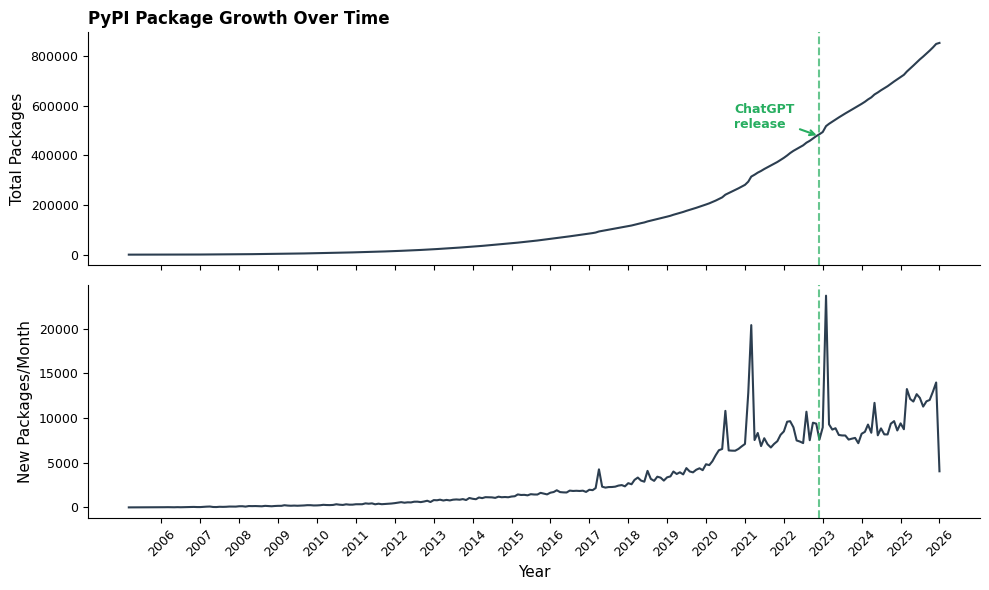

In [ ]:
monthly_df['month'] = pd.to_datetime(monthly_df['month'].astype(str).str.replace(' UTC', ''))
monthly_df = monthly_df.sort_values('month')
monthly_df['total_packages'] = monthly_df['new_packages'].cumsum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(monthly_df['month'], monthly_df['total_packages'], color='#2c3e50', lw=1.5)
ax1.set_ylabel('Total Packages')
ax1.set_title('PyPI Package Growth Over Time', loc='left', fontweight='bold')

ax2.plot(monthly_df['month'], monthly_df['new_packages'], color='#2c3e50', lw=1.5)
ax2.set_ylabel('New Packages/Month')
ax2.set_xlabel('Year')

years = pd.date_range(start='2006-01-01', end='2026-01-01', freq='YS')
ax2.set_xticks(years)
ax2.set_xticklabels([y.year for y in years], rotation=45)

chatgpt_date = pd.Timestamp('2022-11-30')
for ax in [ax1, ax2]: ax.axvline(chatgpt_date, color='#27ae60', linestyle='--', lw=1.5, alpha=0.7)

ax1.annotate('ChatGPT\nrelease', xy=(chatgpt_date, monthly_df.loc[monthly_df['month'] <= chatgpt_date, 'total_packages'].iloc[-1]),
             xytext=(chatgpt_date - pd.Timedelta(days=800), monthly_df['total_packages'].max() * 0.6),
             fontsize=9, color='#27ae60', fontweight='bold', arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5))

plt.tight_layout()
savefig('./so-where-are-all-the-ai-apps/chart_01_pypi_package_creation.png')

In [ ]:
hist_df = counts.groupby(['cohort','cohort_year','is_ai'],as_index=False).agg(val=pd.NamedAgg('n','median'),n=pd.NamedAgg('n','count'))
print(hist_df.head(5).to_markdown())

|    |   cohort |   cohort_year | is_ai   |   val |   n |
|---:|---------:|--------------:|:--------|------:|----:|
|  0 |     2014 |          2014 | False   |     6 | 641 |
|  1 |     2014 |          2014 | True    |     6 |  31 |
|  2 |     2014 |          2015 | False   |     2 | 645 |
|  3 |     2014 |          2015 | True    |     2 |  31 |
|  4 |     2014 |          2016 | False   |     2 | 646 |


In [ ]:
grey, orange_c = '#cccccc', '#e67e22'
post_cs = ['#e67e22', '#e67e22', '#e67e22']
ann_c = '#444444'
chatgpt_x = 2022 + 11/12

def _annotate(ax, x, y, n, c, off=(0,15)):
    ax.annotate(f'{y:.0f}', xy=(x, y), xytext=off, textcoords='offset points', ha='center', fontsize=7, fontweight='bold', color=c)
    ax.annotate(f'(n={n})', xy=(x, y), xytext=(off[0], off[1]-8), textcoords='offset points', ha='center', fontsize=7, color=c)

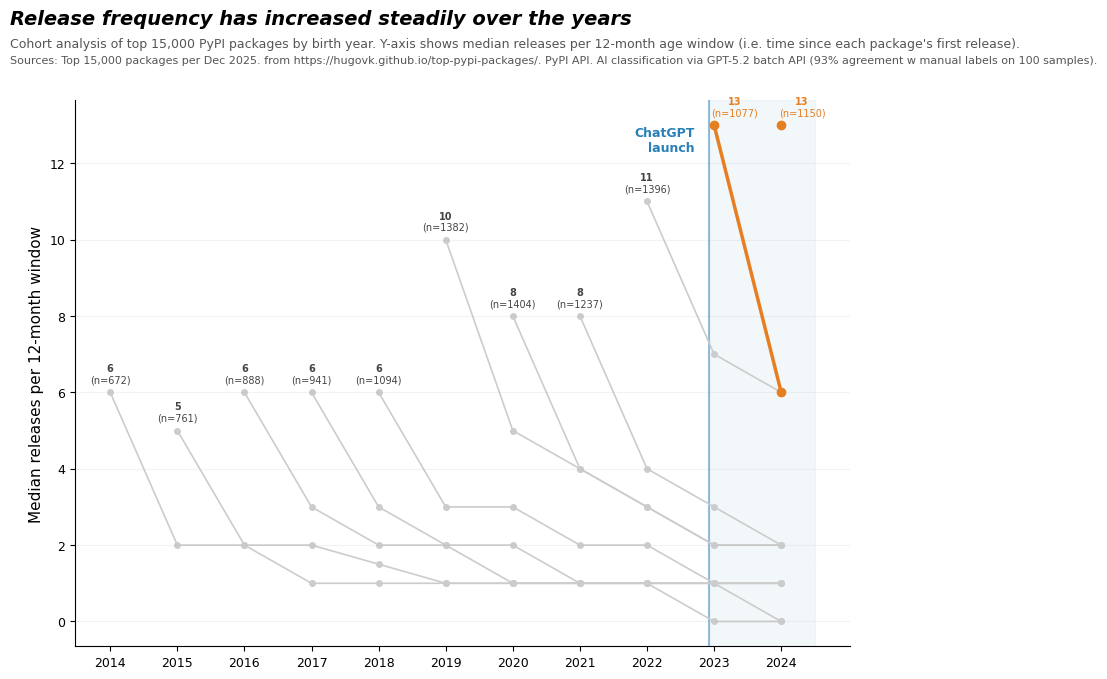

In [ ]:
hist_all = counts.groupby(['cohort','cohort_year'], as_index=False).agg(
    val=pd.NamedAgg('n','median'), n=pd.NamedAgg('n','count'))

grey, orange_c = '#cccccc', '#e67e22'

fig, ax = plt.subplots(figsize=(10, 7))
ax.yaxis.grid(True, linestyle='-', alpha=0.15, zorder=0)
ax.axvspan(chatgpt_x, end_dt.year - 0.5, color='#d4e6f1', alpha=0.3, zorder=0)
ax.axvline(x=chatgpt_x, color='#2980b9', linestyle='-', alpha=0.5, linewidth=1.5, zorder=1)

for cn, g in hist_all.groupby('cohort'):
    is_post = cn >= 2023
    c = orange_c if is_post else grey
    lw, ms, z = (2.5, 6, 3) if is_post else (1.2, 4, 1)
    ax.plot(g['cohort_year'], g['val'], color=c, marker='o', lw=lw, ms=ms, zorder=z)
    off = (15, 15) if is_post else (0, 15)
    _annotate(ax, g['cohort_year'].iloc[0], g['val'].iloc[0], g['n'].iloc[0], c if is_post else ann_c, off)
ymax = ax.get_ylim()[1]
ax.text(chatgpt_x - 0.2, 0.95*ymax, 'ChatGPT\nlaunch', fontsize=9, color='#2980b9',
        va='top', ha='right', fontweight='bold')
ax.set_xticks(range(start_dt.year, end_dt.year))
ax.set_ylabel('Median releases per 12-month window', fontsize=11, fontweight='medium')


fig.text(0.06, 0.98, "Release frequency has increased steadily over the years",
    fontsize=14, fontweight='bold', va='top', fontstyle='italic')
fig.text(0.06, 0.94,
    "Cohort analysis of top 15,000 PyPI packages by birth year. Y-axis shows median releases per 12-month age window (i.e. time since each package's first release).",
    fontsize=9, va='top', color='#555555')
fig.text(0.06, 0.90,
    "Sources: Top 15,000 packages per Dec 2025. from https://hugovk.github.io/top-pypi-packages/. PyPI API. AI classification via GPT-5.2 batch API (93% agreement w manual labels on 100 samples).",
    fontsize=8, va='bottom', color='#555555')
plt.subplots_adjust(top=0.85, bottom=0.07)
savefig('./so-where-are-all-the-ai-apps/chart_02_releases_by_cohort_single.png')

### AI split

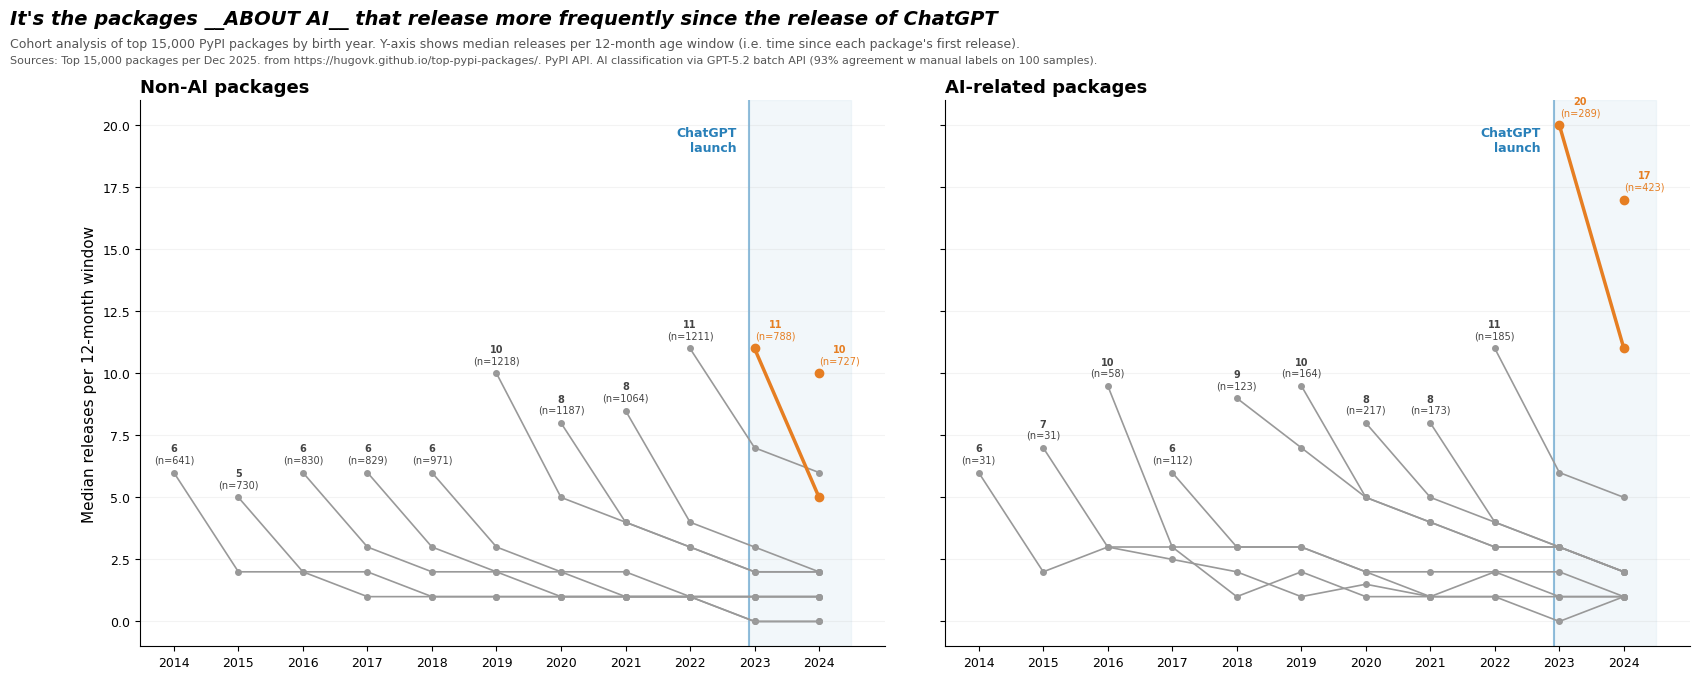

In [ ]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
for ax, is_ai, title in [(ax_l, False, 'Non-AI packages'), (ax_r, True, 'AI-related packages')]:
    grps = [(cn,g) for (cn,ia),g in hist_df.groupby(['cohort','is_ai'], sort=True) if ia==is_ai]
    pre  = [(cn,g) for cn,g in grps if cn < 2023]
    post = [(cn,g) for cn,g in grps if cn >= 2023]
    pre_cs = ['#999999'] * len(pre)
    ax.yaxis.grid(True, linestyle='-', alpha=0.15, zorder=0)
    ax.axvspan(chatgpt_x, end_dt.year - 0.5, color='#d4e6f1', alpha=0.3, zorder=0)
    ax.axvline(x=chatgpt_x, color='#2980b9', linestyle='-', alpha=0.5, linewidth=1.5, zorder=1)
    for i,(cn,g) in enumerate(pre):
        ax.plot(g['cohort_year'], g['val'], color=pre_cs[i], marker='o', lw=1.2, ms=4, zorder=1)
        _annotate(ax, g['cohort_year'].iloc[0], g['val'].iloc[0], g['n'].iloc[0], ann_c)        
    for i,(cn,g) in enumerate(post):
        c = post_cs[min(i, len(post_cs)-1)]
        ax.plot(g['cohort_year'], g['val'], color=c, marker='o', lw=2.5, ms=6, zorder=3)
        _annotate(ax, g['cohort_year'].iloc[0], g['val'].iloc[0], g['n'].iloc[0], c, off=(15,15))

    ax.set_xticks(range(start_dt.year, end_dt.year))
    ax.set_title(title, fontsize=13, fontweight='bold', loc='left')

ymax = ax_l.get_ylim()[1]
for ax in [ax_l, ax_r]:
    ax.text(chatgpt_x - 0.2, 0.95*ymax, 'ChatGPT\nlaunch', fontsize=9, color='#2980b9', va='top', ha='right', fontweight='bold')
ax_l.set_ylabel('Median releases per 12-month window', fontsize=11, fontweight='medium')
fig.text(0.06, 0.98, "It's the packages __ABOUT AI__ that release more frequently since the release of ChatGPT",
    fontsize=14, fontweight='bold', va='top', fontstyle='italic')
fig.text(0.06, 0.94, "Cohort analysis of top 15,000 PyPI packages by birth year. Y-axis shows median releases per 12-month age window (i.e. time since each package's first release).",
    fontsize=9, va='top', color='#555555')
fig.text(0.06, 0.90,
    "Sources: Top 15,000 packages per Dec 2025. from https://hugovk.github.io/top-pypi-packages/. PyPI API. AI classification via GPT-5.2 batch API (93% agreement w manual labels on 100 samples).",
    fontsize=8, va='bottom', color='#555555')
plt.subplots_adjust(top=0.85, bottom=0.07, wspace=0.08)
savefig('./so-where-are-all-the-ai-apps/chart_03_releases_by_cohort_and_ai.png')

Alternative chart with just each cohort's first twelve months of releases:

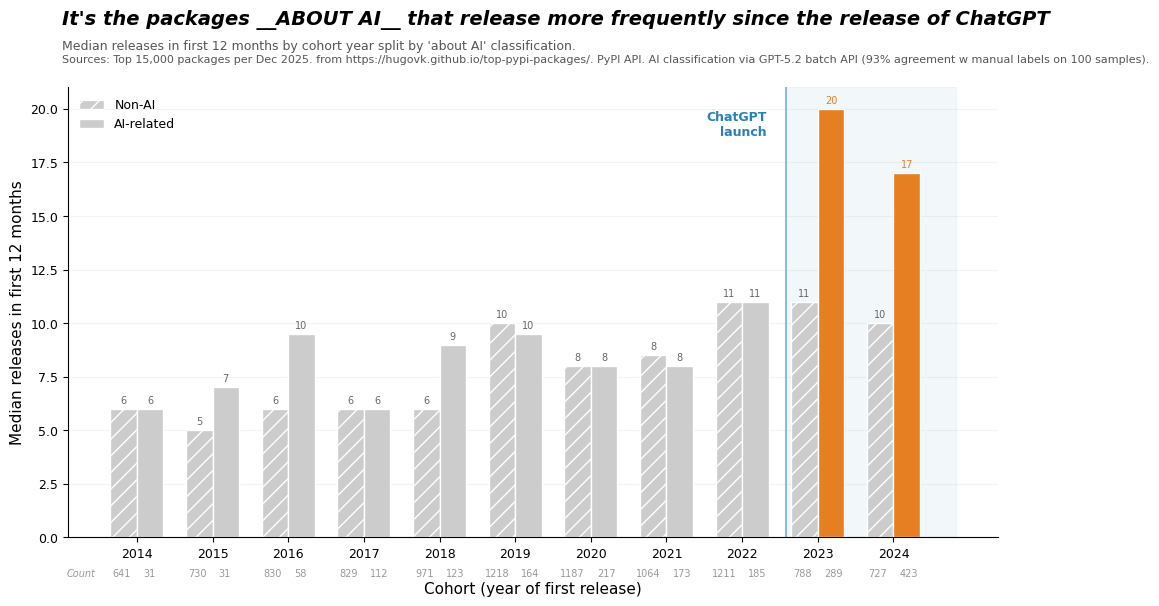

In [ ]:
from matplotlib.transforms import blended_transform_factory

age0 = counts[counts['age']==0]
s = age0.groupby(['cohort','is_ai']).agg(med=('n','median'), cnt=('n','size')).reset_index()
cohorts = sorted(s['cohort'].unique())
x, w = np.arange(len(cohorts)), 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.yaxis.grid(True, linestyle='-', alpha=0.15, zorder=0)
ax.axvspan(cohorts.index(2023)-0.25, len(cohorts), color='#d4e6f1', alpha=0.3, zorder=0)
ax.axvline(x=cohorts.index(2023)-0.25, color='#2980b9', linestyle='-', alpha=0.5, lw=1.5, zorder=1)

n_table = {}
for i, (is_ai, lbl, hatch) in enumerate([(False, 'Non-AI', '//'), (True, 'AI-related', None)]):
    d = s[s['is_ai']==is_ai].set_index('cohort').reindex(cohorts)
    vals, ns = d['med'].fillna(0).values, d['cnt'].fillna(0).values.astype(int)
    n_table[lbl] = ns
    pre, post = np.array([c < 2023 for c in cohorts]), np.array([c >= 2023 for c in cohorts])
    if is_ai:
        ax.bar(x[pre]+i*w, vals[pre], w, fc=grey, ec='white', zorder=2, label=lbl)
        ax.bar(x[post]+i*w, vals[post], w, fc=orange_c, ec='white', zorder=2)
    else:
        ax.bar(x+i*w, vals, w, fc=grey, hatch=hatch, ec='white', zorder=2, label=lbl)
    for j in range(len(cohorts)):
        clr = orange_c if is_ai and cohorts[j] >= 2023 else '#666'
        ax.annotate(f'{vals[j]:.0f}', xy=(x[j]+i*w, vals[j]),
                    xytext=(0,4), textcoords='offset points', ha='center', fontsize=7, color=clr)

ymax = ax.get_ylim()[1]
ax.text(cohorts.index(2023)-0.5, ymax*0.95, 'ChatGPT\nlaunch', fontsize=9, color='#2980b9',
        ha='right', va='top', fontweight='bold')
ax.set_xticks(x + w/2); ax.set_xticklabels(cohorts)
ax.set_xlabel('Cohort (year of first release)', labelpad=15)
ax.set_ylabel('Median releases in first 12 months')
ax.legend(loc='upper left')

# Count row below x-axis
trans = blended_transform_factory(ax.transData, ax.transAxes)
y_row = -0.08
ax.text(-0.75, y_row, 'Count', transform=trans, fontsize=7, color='#999',
        ha='left', va='center', fontstyle='italic', clip_on=False)
for j in range(len(cohorts)):
    tick_x = x[j] + w/2
    ax.text(tick_x - 0.08, y_row, str(n_table['Non-AI'][j]), transform=trans, fontsize=7,
            color='#999', ha='right', va='center', clip_on=False)
    ax.text(tick_x + 0.08, y_row, str(n_table['AI-related'][j]), transform=trans, fontsize=7,
            color='#999', ha='left', va='center', clip_on=False)

fig.text(0.12, 0.98, "It's the packages __ABOUT AI__ that release more frequently since the release of ChatGPT",
    fontsize=14, fontweight='bold', va='top', fontstyle='italic')
fig.text(0.12, 0.93,
    "Median releases in first 12 months by cohort year split by 'about AI' classification.",
    fontsize=9, va='top', color='#555')
fig.text(0.12, 0.905,
    "Sources: Top 15,000 packages per Dec 2025. from https://hugovk.github.io/top-pypi-packages/. PyPI API. AI classification via GPT-5.2 batch API (93% agreement w manual labels on 100 samples).",
    fontsize=8, va='top', color='#555')
plt.subplots_adjust(top=0.85, bottom=0.10)
savefig('./so-where-are-all-the-ai-apps/chart_05_bars_ai_vs_nonai.png')

Now lets make a 2x2 version

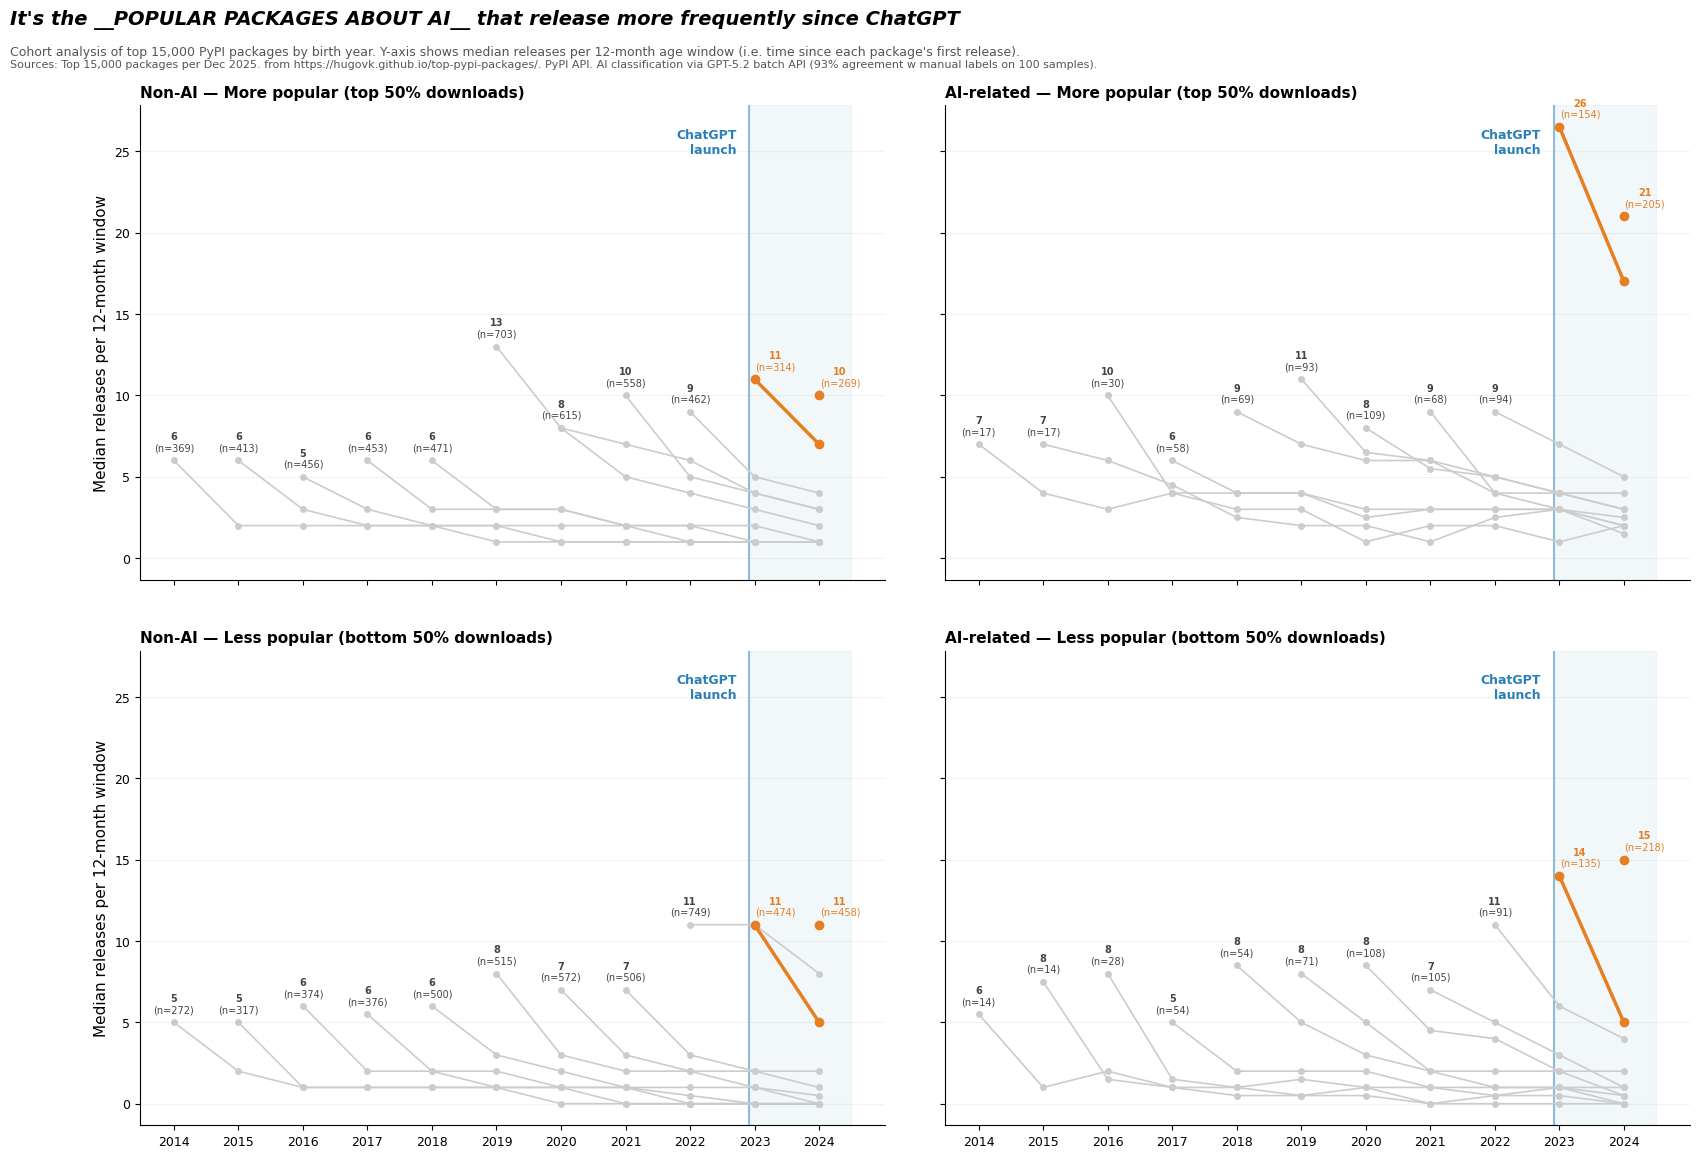

In [ ]:
hist_df2 = counts.groupby(['cohort','cohort_year','is_ai','top_half'],as_index=False).agg(
    val=pd.NamedAgg('n','median'), n=pd.NamedAgg('n','count'))

fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True, sharex=True)
for row, (th, th_lbl) in enumerate([(True, 'More popular (top 50% downloads)'), (False, 'Less popular (bottom 50% downloads)')]):
    for col, (is_ai, ai_lbl) in enumerate([(False, 'Non-AI'), (True, 'AI-related')]):
        ax = axes[row][col]
        sub = hist_df2[(hist_df2['is_ai']==is_ai) & (hist_df2['top_half']==th)]
        grps = [(cn,g) for cn,g in sub.groupby('cohort', sort=True)]
        pre  = [(cn,g) for cn,g in grps if cn < 2023]
        post = [(cn,g) for cn,g in grps if cn >= 2023]
        ax.yaxis.grid(True, linestyle='-', alpha=0.15, zorder=0)
        ax.axvspan(chatgpt_x, end_dt.year - 0.5, color='#d4e6f1', alpha=0.3, zorder=0)
        ax.axvline(x=chatgpt_x, color='#2980b9', linestyle='-', alpha=0.5, linewidth=1.5, zorder=1)
        for i,(cn,g) in enumerate(pre):
            ax.plot(g['cohort_year'], g['val'], color=grey, marker='o', lw=1.2, ms=4, zorder=1)
            _annotate(ax, g['cohort_year'].iloc[0], g['val'].iloc[0], g['n'].iloc[0], ann_c)
        for i,(cn,g) in enumerate(post):
            c = post_cs[min(i, len(post_cs)-1)]
            ax.plot(g['cohort_year'], g['val'], color=c, marker='o', lw=2.5, ms=6, zorder=3)
            _annotate(ax, g['cohort_year'].iloc[0], g['val'].iloc[0], g['n'].iloc[0], c, off=(15,15))
        ax.set_xticks(range(start_dt.year, end_dt.year))
        ax.set_title(f'{ai_lbl} — {th_lbl}', fontsize=11, fontweight='bold', loc='left')
    axes[row][0].set_ylabel('Median releases per 12-month window')

ymax = axes[0][0].get_ylim()[1]
for ax in axes.flat:
    ax.text(chatgpt_x - 0.2, 0.95*ymax, 'ChatGPT\nlaunch', fontsize=9, color='#2980b9', va='top', ha='right', fontweight='bold')
fig.text(0.06, 0.98, "It's the __POPULAR PACKAGES ABOUT AI__ that release more frequently since ChatGPT",
    fontsize=14, fontweight='bold', va='top', fontstyle='italic')
fig.text(0.06, 0.95,
    "Cohort analysis of top 15,000 PyPI packages by birth year. Y-axis shows median releases per 12-month age window (i.e. time since each package's first release).",
    fontsize=9, va='top', color='#555555')
fig.text(0.06, 0.93,
    "Sources: Top 15,000 packages per Dec 2025. from https://hugovk.github.io/top-pypi-packages/. PyPI API. AI classification via GPT-5.2 batch API (93% agreement w manual labels on 100 samples).",
    fontsize=8, va='bottom', color='#555555')
plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.08, hspace=0.15)
savefig('./so-where-are-all-the-ai-apps/chart_04_releases_2x2.png')

Alternative chart with just each cohort's first twelve months of releases:

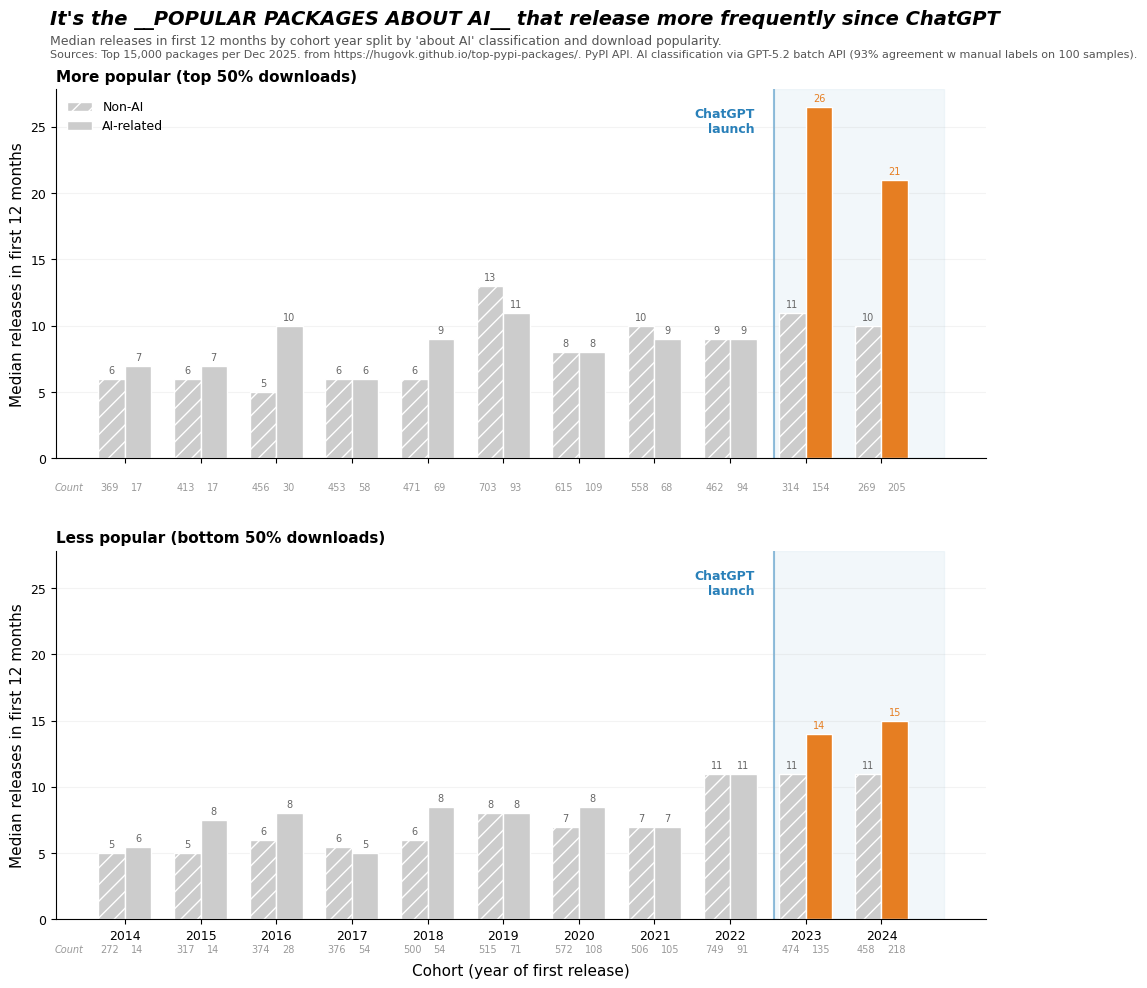

In [ ]:
age0 = counts[counts['age']==0]
s = age0.groupby(['cohort','is_ai','top_half']).agg(med=('n','median'), cnt=('n','size')).reset_index()
cohorts = sorted(s['cohort'].unique())
x, w = np.arange(len(cohorts)), 0.35

fig, (ax_t, ax_b) = plt.subplots(2, 1, figsize=(12, 10), sharey=True, sharex=True)
for ax, th, title in [(ax_t, True, 'More popular (top 50% downloads)'), (ax_b, False, 'Less popular (bottom 50% downloads)')]:
    sub = s[s['top_half']==th]
    ax.yaxis.grid(True, linestyle='-', alpha=0.15, zorder=0)
    ax.axvspan(cohorts.index(2023)-0.25, len(cohorts), color='#d4e6f1', alpha=0.3, zorder=0)
    ax.axvline(x=cohorts.index(2023)-0.25, color='#2980b9', linestyle='-', alpha=0.5, lw=1.5, zorder=1)
    n_table = {}
    for i, (is_ai, lbl, hatch) in enumerate([(False, 'Non-AI', '//'), (True, 'AI-related', None)]):
        d = sub[sub['is_ai']==is_ai].set_index('cohort').reindex(cohorts)
        vals, ns = d['med'].fillna(0).values, d['cnt'].fillna(0).values.astype(int)
        n_table[lbl] = ns
        pre, post = np.array([c < 2023 for c in cohorts]), np.array([c >= 2023 for c in cohorts])
        if is_ai:
            ax.bar(x[pre]+i*w, vals[pre], w, fc=grey, ec='white', zorder=2, label=lbl if ax is ax_t else None)
            post_c = orange_c # if ax is ax_t else grey
            ax.bar(x[post]+i*w, vals[post], w, fc=post_c, ec='white', zorder=2)
        else:
            ax.bar(x+i*w, vals, w, fc=grey, hatch=hatch, ec='white', zorder=2, label=lbl if ax is ax_t else None)
        for j in range(len(cohorts)):
            clr = orange_c if is_ai and cohorts[j] >= 2023 else '#666'
            ax.annotate(f'{vals[j]:.0f}', xy=(x[j]+i*w, vals[j]),
                        xytext=(0,4), textcoords='offset points', ha='center', fontsize=7, color=clr)
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel('Median releases in first 12 months')
    # Count row below x-axis
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    y_row = -0.08
    ax.text(-0.75, y_row, 'Count', transform=trans, fontsize=7, color='#999',
            ha='left', va='center', fontstyle='italic', clip_on=False)
    for j in range(len(cohorts)):
        tick_x = x[j] + w/2
        ax.text(tick_x - 0.08, y_row, str(n_table['Non-AI'][j]), transform=trans, fontsize=7,
                color='#999', ha='right', va='center', clip_on=False)
        ax.text(tick_x + 0.08, y_row, str(n_table['AI-related'][j]), transform=trans, fontsize=7,
                color='#999', ha='left', va='center', clip_on=False)

ymax = ax_t.get_ylim()[1]
for ax in [ax_t, ax_b]:
    ax.text(cohorts.index(2023)-0.5, ymax*0.95, 'ChatGPT\nlaunch', fontsize=9, color='#2980b9',
            ha='right', va='top', fontweight='bold')
ax_b.set_xticks(x + w/2); ax_b.set_xticklabels(cohorts)
ax_b.set_xlabel('Cohort (year of first release)', labelpad=15)
ax_t.legend(loc='upper left')
fig.text(0.12, 0.98, "It's the __POPULAR PACKAGES ABOUT AI__ that release more frequently since ChatGPT",
    fontsize=14, fontweight='bold', va='top', fontstyle='italic')
fig.text(0.12, 0.955,
    "Median releases in first 12 months by cohort year split by 'about AI' classification and download popularity.",
    fontsize=9, va='top', color='#555')
fig.text(0.12, 0.94,
    "Sources: Top 15,000 packages per Dec 2025. from https://hugovk.github.io/top-pypi-packages/. PyPI API. AI classification via GPT-5.2 batch API (93% agreement w manual labels on 100 samples).",
    fontsize=8, va='top', color='#555')
plt.subplots_adjust(top=0.90, bottom=0.07, hspace=0.25)
savefig('./so-where-are-all-the-ai-apps/chart_06_bars_2pane.png')